# Детекция автоматизированного сбора данных (ботов) на Авито

**Задача:** по событиям пользователя за суточное окно наблюдения предсказать вероятность того, что `cookie_id` принадлежит известному сервису автоматизированного сбора данных, а не человеку.
**Метрика соревнования:** Precision при Recall ≥ 0.70 (считается по `cookie_id`).
**Итоговая модель:** одиночный CatBoost, обученный на полном train с upweighting'ом мобильных ботов и усреднением по 5 сидам (seed-bagging).

---

## Как читать этот ноутбук

Это финальная, воспроизводимая версия пайплайна — она содержит весь код, необходимый для того, чтобы дойти от сырых `data/*.csv` до `submission.csv`, отправленного на платформу.

Перед тем как дойти до этой версии, было проведено значительно больше экспериментов, чем показано здесь: сравнение нескольких моделей (LightGBM, XGBoost, CatBoost, Random Forest) и их ансамблей, подбор гиперпараметров через Optuna, ablation-тесты по блокам признаков, стресс-тесты на устойчивость (Leave-One-Cluster-Out, отключение топового признака) и так далее. Эти эксперименты проводились отдельно и не пересчитываются заново в этом файле — иначе ноутбук был бы избыточно длинным и медленным для проверки. 


## Краткое описание подхода

1. **EDA** (проведён отдельно, ключевые находки — в разделе 2) выявил: сильный дисбаланс классов (~8% ботов), строгую OOT-структуру train/test (train — две календарные недели, test — следующая неделя), критичную ловушку утечки данных (события и показы капчи после окончания окна наблюдения) и 4 разных поведенческих архетипа среди ботов.
2. **Feature engineering**: из сырых событий собран набор из 76 поведенческих признаков (объём активности, тайминги, курсор мыши, User-Agent, глубина пагинации, со-визитация объявлений, мобильные паттерны, unsupervised anomaly score) — подробности в разделе 4, полная реализация — в модуле `features.py`.
3. **Валидация**: строго временная схема (5-fold Walk-Forward), потому что случайный K-Fold на данных с выраженной временной структурой даёт завышенную и нерепрезентативную оценку качества.
4. **Выбор модели**: построена лестница от простых бейзлайнов (случайный скор → эвристика → логрег) до градиентного бустинга; среди CatBoost / LightGBM / XGBoost и их ансамблей лучшим по совокупности качества и простоты оказался **одиночный CatBoost** — подробное обоснование в разделе 6.
5. **Финальная конфигурация**: CatBoost с лёгким upweighting'ом мобильных ботов (самый крупный и самый сложный для модели архетип) и усреднением по 5 сидам для снижения дисперсии предсказаний.
6. **Диагностика**: проверка полноты обнаружения по каждому из 4 архетипов, устойчивости к потере главного признака и корректности формата итогового файла.


In [1]:
# --- Стандартные библиотеки и утилиты ---
import os
import sys
import time
import warnings

# --- Работа с данными ---
import numpy as np
import pandas as pd

# --- Визуализация (используется только для графика важности признаков в разделе 8) ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- ML: бейзлайны и вспомогательные шаги ---
from sklearn.preprocessing import StandardScaler     # нормализация признаков для логрег-бейзлайна
from sklearn.cluster import KMeans                    # разметка 4 поведенческих архетипов ботов (только диагностика, не признак)
from sklearn.linear_model import LogisticRegression   # интерпретируемый ML-бейзлайн (раздел 6)
from sklearn.ensemble import IsolationForest           # для справки: тем же классом в features.py посчитан anomaly_score_iforest (блок I)

# --- Финальная модель ---
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Единый сид для всех детерминированных шагов ноутбука (KMeans, бейзлайны и т.д.).
# Финальная модель дополнительно бэггируется по списку из 5 фиксированных сидов
# (раздел 7) — это сделано специально, чтобы усреднить случайность инициализации
# CatBoost, а не полагаться на один сид.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"Окружение инициализировано. Python {sys.version.split()[0]}")

Окружение инициализировано. Python 3.12.4


In [2]:
def precision_at_recall(y_true: np.ndarray, score: np.ndarray, target_recall: float = 0.70) -> float:
    """
    Официальная метрика соревнования: максимальный Precision среди порогов,
    при которых Recall >= target_recall.

    Ключевой нюанс реализации: пороги перебираются НЕ по каждому объекту, а по
    границам групп одинаковых score (переменная `ends`). Это напрямую
    соответствует условию задачи -- "одинаковые score обрабатываются одной
    группой: отмечаются либо все cookie с таким значением, либо ни одна".
    Наивная реализация "порог = значение score конкретного объекта" завысила
    бы метрику, разрешив разрезать группу с одинаковым score пополам.
    """
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)

    # Сортируем по убыванию score: идём от самых уверенных предсказаний к менее уверенным
    order = np.argsort(-score, kind='mergesort')
    y, s = y_true[order], score[order]

    n_pos = int(y.sum())
    if n_pos == 0:
        return 0.0

    tp = np.cumsum(y)                    # число найденных ботов среди первых k объектов
    k = np.arange(1, len(y) + 1)
    ends = np.r_[s[1:] != s[:-1], True]  # True на последнем объекте каждой группы одинаковых score

    precisions = tp[ends] / k[ends]
    recalls = tp[ends] / n_pos

    # Среди порогов, где полнота >= 0.70, берём максимальную точность
    valid_idx = np.where(recalls >= target_recall)[0]
    if len(valid_idx) == 0:
        return 0.0

    return float(np.max(precisions[valid_idx]))


def get_threshold_and_cluster_recalls(y_true, score, bot_clusters, target_recall=0.70):
    """
    То же самое, что precision_at_recall, но дополнительно возвращает:
      - сам оптимальный порог t*,
      - полноту (recall) отдельно по каждому из 4 поведенческих архетипов ботов.

    Используется только для диагностики (какие типы ботов модель находит хуже
    остальных), а не для обучения или отбора порога для сабмишна -- порог для
    submission.csv не нужен, платформа сама перебирает пороги по итоговому score.
    """
    y_true, score, bot_clusters = np.asarray(y_true, int), np.asarray(score, float), np.asarray(bot_clusters)
    order = np.argsort(-score, kind='mergesort')
    y, s = y_true[order], score[order]
    n_pos = int(y.sum())
    if n_pos == 0:
        return 0.0, 0.0, {}
    tp = np.cumsum(y)
    k = np.arange(1, len(y) + 1)
    ends = np.r_[s[1:] != s[:-1], True]
    precisions, recalls, thresholds = tp[ends] / k[ends], tp[ends] / n_pos, s[ends]
    valid_idx = np.where(recalls >= target_recall)[0]
    if len(valid_idx) == 0:
        return 0.0, 0.0, {}
    best_i = valid_idx[np.argmax(precisions[valid_idx])]
    best_thresh, best_prec = float(thresholds[best_i]), float(precisions[best_i])
    is_selected = score >= best_thresh
    cluster_recalls = {}
    for c in sorted(np.unique(bot_clusters[y_true == 1])):
        mask_c = (y_true == 1) & (bot_clusters == c)
        if mask_c.sum() > 0:
            cluster_recalls[int(c)] = float(is_selected[mask_c].mean())
    return best_thresh, best_prec, cluster_recalls

---

## 2. Ключевые находки EDA, определившие архитектуру решения

EDA проводился отдельно (см. папку eda) на `train.csv`, `test.csv` и `events.csv.gz`. Здесь приведены только выводы, которые напрямую повлияли на устройство пайплайна ниже — полный EDA в этом файле не воспроизводится.

**1. Сильный дисбаланс классов.** В train 11 091 cookie, из них ботов — 899 (8.11%). Соотношение классов ≈ 1 : 11.3. Отсюда два следствия: (а) обучению нужен `class_weight` / `sample_weight`, (б) базовый уровень метрики для случайного скора ≈ 0.08 — от этого числа отсчитывается любой дальнейший прогресс.

**2. Строгая OOT-структура train/test.** Train — ровно две календарные недели (06.04–19.04.2026), test — следующая неделя (20.04–26.04.2026), без пересечения по времени. Случайный K-Fold в такой ситуации даёт завышенную, нерепрезентативную оценку качества модели. Поэтому валидация построена строго по времени (раздел 5).

**3. Критическая ловушка утечки данных.** В сырых событиях train нашлось 40 779 событий, произошедших **после** `window_end_ts` соответствующей cookie — и среди них 100% (7 928 из 7 928) показов капчи (`captcha_shown`). Капча здесь — по сути, post-factum подтверждение того, что cookie оказалась ботом (антифрод поймал её на следующие сутки после окна наблюдения), и такого рода событий физически не может быть в test, где все события строго внутри окна. Если не отфильтровать события по инварианту `window_start_ts <= event_ts < window_end_ts`, модель научится определять ботов по капче «из будущего» и полностью провалится на скрытом тесте, где этого сигнала нет. Этот инвариант — жёсткое, проверяемое требование ко всему пайплайну (раздел 3).

**4. Курсор мыши осмыслен только на десктопе.** На мобильных платформах `pointer_x`/`pointer_y` отсутствуют физически (100% NaN и у людей, и у ботов) — это не сигнал, а особенность сенсорного экрана. На десктопе же боты либо вовсе не двигают курсор (прямые HTTP-скрипты), либо двигают его неестественно равномерно (эмуляция мыши в headless-браузерах). Признаки на основе курсора считаются только по подмножеству desktop/web-событий (блок D).

**5. Четыре разных поведенческих архетипа ботов.** Неконтролируемая кластеризация положительного класса по поведенческим признакам выявила 4 разных «почерка» автоматизации:

| Архетип | Доля | Поведение |
|---|---|---|
| Кластер 0 — агрессивный краулер | ~18% | Очень глубокая пагинация выдачи, высокая скорость запросов |
| Кластер 1 — прямой HTTP-скрипт | ~5% | `curl` / `Scrapy` / `python-requests` в User-Agent, минимум «человеческих» действий |
| Кластер 2 — мобильный эмулятор | ~33% | Только мобильные устройства, фокус на карточках продавца и выгрузке контактов, курсора нет физически |
| Кластер 3 — stealth-бот | ~44% | Десктоп, эмулирует движения мыши, умеренная скорость — маскируется под обычного пользователя |

Ключевой вывод отсюда: раз положительный класс неоднороден, набор признаков должен закрывать все 4 «почерка» одновременно, а не один доминирующий паттерн — иначе модель хорошо ловит один тип бота и упускает остальные.

In [3]:
# Загружаем метаданные окон наблюдения и сразу проверяем, что цифры совпадают с тем,
# что было найдено на этапе EDA (раздел 2), простой sanity-check перед тем, как
# переходить к построению признаков.
train_meta = pd.read_csv('data/train.csv', parse_dates=['window_start_ts', 'window_end_ts'])
test_meta = pd.read_csv('data/test.csv', parse_dates=['window_start_ts', 'window_end_ts'])

print(f"Размер Train: {len(train_meta)} кук | Ботов: {train_meta.target.sum()} ({train_meta.target.mean():.2%})")
print(f"Размер Test:  {len(test_meta)} кук")
print(f"Период Train: {train_meta.window_start_ts.min().date()} — {train_meta.window_end_ts.max().date()}")
print(f"Период Test:  {test_meta.window_start_ts.min().date()} — {test_meta.window_end_ts.max().date()}")

Размер Train: 11091 кук | Ботов: 899 (8.11%)
Размер Test:  4909 кук
Период Train: 2026-04-06 — 2026-04-20
Период Test:  2026-04-20 — 2026-04-27


---

## 3. Препроцессинг событий: обязательные инварианты

Все признаки строятся из `events.csv.gz` в модуле `features.py` (импортируется в следующем разделе). Реализация вынесена в отдельный файл, а не в ячейки ноутбука, чтобы не загромождать основной пайплайн и переиспользовать её одинаково для train и test. Что было сделано:

1. `drop_duplicates()` по полным дубликатам строк (в сырых событиях их около 5 тыс.) — при этом события, произошедшие в одну секунду, но с разными `item_id`/`item_category` (параллельные вкладки/запросы), не считаются дублями и не удаляются.
2. `platform.str.lower()` — единственное поле с «грязным» регистром (`Web` / `WEB` / `web` и т.п.).
3. Сортировка событий по `(cookie_id, event_ts)` — обязательна перед расчётом любых временных дельт.
4. **Жёсткий полуоткрытый фильтр окна:** `window_start_ts <= event_ts < window_end_ts`. Правая граница исключена намеренно — иначе в train попали бы единичные события ровно в 00:00:00 следующих суток, которых структурно не может быть в test.
5. Assert на то, что после фильтрации в данных не осталось ни одного `captcha_shown` — это событие целиком лежит за пределами окна наблюдения и является чистой утечкой, если инвариант (4) нарушен.

## 4. Признаки: 76 поведенческих характеристик cookie

Итоговый фичсет закрывает все 4 архетипа ботов из раздела 2, а не один доминирующий паттерн:

| Блок | Что измеряет | Примеры признаков |
|---|---|---|
| **A** — объём и активность | Сколько и что делала cookie | число событий, доли событий по типам, события в час |
| **B** — возраст cookie | «Свежесть» identity на начало окна | возраст cookie в часах на момент `window_start_ts` |
| **C** — временная динамика | Скорость и регулярность действий | медиана/квантили Δt между событиями, доля сверхбыстрых действий (<1с), ночная активность |
| **D** — курсор на десктопе | Естественность движений мыши | std координат, медианный шаг курсора, доля событий с заполненным pointer (только desktop/web) |
| **E** — User-Agent и платформа | Признаки автоматизации в UA | флаг известных скрапинг-библиотек, семейство ОС/браузера, тип платформы |
| **F** — каталог и со-визитация | Глубина обхода и совпадения с другими cookie | максимальная страница выдачи, отношение локаций к категориям, среднее число других посетителей тех же объявлений |
| **G** — мобильные паттерны | Специфика мобильного скрапинга | флаг «только мобильные события», доля контактных действий |
| **I** — unsupervised anomaly score | Общая «нетипичность» поведения | `anomaly_score_iforest` — выход `IsolationForest`, обученного без разметки на train+test |

Блок F (глубина пагинации + со-визитация объявлений) на практике оказался главным драйвером качества — подробнее в разделе 8.

**Блок H (последовательности переходов между типами событий, например `search → search → item`) был построен, но исключён из финального фичсета.** В ходе ablation-тестов (отдельный этап экспериментов) выяснилось, что он дублирует информацию, уже присутствующую в блоке F (в первую очередь — признак монотонности пагинации), и его удаление не ухудшает, а слегка улучшает метрику за счёт снижения шума. В следующей ячейке он исключается явно, вместе с 7 признаками, у которых важность (Gain) оказалась нулевой на всех фолдах валидации.


In [4]:
# Признаки -- самый затратный по времени шаг пайплайна (агрегация ~330 тыс. событий
# по каждой cookie), поэтому результат кэшируется в Parquet. Если файлов кэша нет
# (например, при первом запуске на новой машине), признаки будут пересчитаны из
# сырых events.csv.gz через features.py -- модуль с полной реализацией всех блоков
# A-I, описанных в разделе 4. Результат идентичен в обоих случаях.
train_feats_path = 'data/features_train.parquet'
test_feats_path = 'data/features_test.parquet'

if os.path.exists(train_feats_path) and os.path.exists(test_feats_path):
    train_feats = pd.read_parquet(train_feats_path)
    test_feats = pd.read_parquet(test_feats_path)
    print("[OK] Признаки успешно загружены из кэша Parquet.")
else:
    print("Генерация признаков из сырых событий (events.csv.gz)...")
    from features import build_all_features
    events_raw = pd.read_csv('data/events.csv.gz', compression='gzip', parse_dates=['event_ts'])
    train_feats = build_all_features(events_raw, train_meta, is_train=True)
    test_feats = build_all_features(events_raw, test_meta, is_train=False)

# Дата окна нужна только для построения временных фолдов валидации (раздел 5) --
# сама по себе она не используется как признак модели (см. exclude_cols ниже).
train_feats['date'] = train_meta['window_start_ts'].dt.date
dates = sorted(train_feats['date'].unique())
y_all = train_feats['target'].values

# --- Формирование финального фичсета ---
# zero_gain: признаки с нулевой важностью (Gain) на всех фолдах валидации -- либо
#            монотонные преобразования уже оставленных признаков, либо константы.
# h_cols:    блок H (последовательности переходов) -- исключён по итогам ablation-теста,
#            дублирует сигнал блока F и не даёт прироста метрики (см. раздел 4).
zero_gain = ['n_events_log1p', 'cookie_age_log', 'cookie_age_days', 'session_span_ratio', 'login_flag', 'platform_changed_flag', 'ua_changed_flag']
h_cols = ['consecutive_same_event_share', 'search_to_search_rate', 'search_to_item_rate', 'item_to_seller_rate']
exclude_cols = ['cookie_id', 'target', 'date', 'bot_cluster'] + zero_gain + h_cols

feature_cols = [c for c in train_feats.columns if c not in exclude_cols]
cat_cols = ['ua_os_family', 'ua_browser_family', 'platform_bucket']  # передаются в CatBoost нативно, без ручного one-hot

print(f"Финальный фичсет: {len(feature_cols)} признаков (включая {len(cat_cols)} категориальных).")

[OK] Признаки успешно загружены из кэша Parquet.
Финальный фичсет: 76 признаков (включая 3 категориальных).


---

## 5. Схема валидации: 5-fold Walk-Forward Time-Series Split

Train и test не пересекаются по времени (раздел 2), поэтому случайный K-Fold здесь неприменим — он позволил бы модели использовать информацию из «будущих» cookie при предсказании «прошлых», завышая оценку качества. Вместо этого используется **расширяющееся окно** (expanding window): каждый следующий фолд обучается на всех предыдущих днях и валидируется на паре следующих:

| Фолд | Train (дни) | Validation (дни) |
|---|---|---|
| 0 | 0–5 | 6–7 |
| 1 | 0–7 | 8–9 |
| 2 | 0–9 | 10–11 |
| 3 | 0–11 | 12–13 |
| 4 (**Holdout**) | 0–6 (Неделя 1) | 7–13 (Неделя 2) |

Последний фолд особенный: он воспроизводит структуру реального сабмишна (обучение строго по первой половине train, проверка на второй половине, с тем же составом дней недели, что и в скрытом test) и далее используется как финальная контрольная точка, а не как рядовой фолд для перебора настроек.

В этом же разделе положительный класс размечается на 4 поведенческих архетипа из раздела 2 (неконтролируемая кластеризация `KMeans` с 4 кластерами по ключевым поведенческим признакам). Эта разметка используется только для диагностики — чтобы дальше видеть, каких именно ботов модель находит хуже, а не как признак или отдельная задача.


In [5]:
# --- 5 фолдов Walk-Forward CV, см. таблицу в разделе 5 ---
wf_splits = [
    (train_feats['date'] <= dates[5], (train_feats['date'] >= dates[6]) & (train_feats['date'] <= dates[7])),
    (train_feats['date'] <= dates[7], (train_feats['date'] >= dates[8]) & (train_feats['date'] <= dates[9])),
    (train_feats['date'] <= dates[9], (train_feats['date'] >= dates[10]) & (train_feats['date'] <= dates[11])),
    (train_feats['date'] <= dates[11], (train_feats['date'] >= dates[12]) & (train_feats['date'] <= dates[13])),
    (train_feats['date'] <= dates[6], train_feats['date'] >= dates[7])  # фолд 4 = Holdout (Неделя 1 -> Неделя 2)
]

# --- Разметка 4 архетипов ботов (только для диагностики полноты обнаружения, не для обучения) ---
# Кластеризуем ТОЛЬКО положительный класс по ключевым поведенческим признакам,
# затем сопоставляем номер кластера с содержательным архетипом по его характерным
# признакам (например, кластер с максимальной search_page_max -- это "агрессивный краулер").
bots = train_feats[train_feats.target == 1].copy()
cluster_cols = [
    'n_events_total', 'dt_median_sec', 'pointer_fill_rate_desktop', 'search_page_max', 
    'share_events_seller_page_view', 'location_nunique', 'category_nunique', 
    'has_desktop_events', 'is_known_scraper_lib', 'cookie_age_days' if 'cookie_age_days' in bots else 'cookie_age_hours'
]
X_cl = StandardScaler().fit_transform(bots[cluster_cols].fillna(0.0))
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
bots['cl'] = kmeans.fit_predict(X_cl)

# Сопоставляем "сырые" номера кластеров KMeans (0-3, порядок случаен) с содержательными
# архетипами по их характерным признакам:
p = bots.groupby('cl')[cluster_cols].mean()
c_agg = p['search_page_max'].idxmax()                     # архетип 0: самая глубокая пагинация -> агрессивный краулер
c_script = p['is_known_scraper_lib'].idxmax()              # архетип 1: явные признаки скрипта в User-Agent
c_mob = p['has_desktop_events'].idxmin()                   # архетип 2: событий с десктопа почти нет -> мобильный эмулятор
c_stealth = [c for c in range(4) if c not in {c_agg, c_script, c_mob}][0]  # архетип 3: всё, что осталось -> stealth-бот
cl_map = {c_agg: 0, c_script: 1, c_mob: 2, c_stealth: 3}
train_feats['bot_cluster'] = -1  # -1 у людей (архетипы определены только для ботов)
train_feats.loc[bots.index, 'bot_cluster'] = bots['cl'].map(cl_map).values

print("Распределение позитивов по 4 архетипам в Train:")
for i, name in enumerate(['0 (Агрессивный краулер)', '1 (HTTP-скрипт)', '2 (Мобильный эмулятор)', '3 (Stealth Web бот)']):
    cnt = (train_feats.bot_cluster == i).sum()
    print(f"  Кластер {name}: {cnt} шт. ({cnt / len(bots):.1%})")

Распределение позитивов по 4 архетипам в Train:
  Кластер 0 (Агрессивный краулер): 162 шт. (18.0%)
  Кластер 1 (HTTP-скрипт): 44 шт. (4.9%)
  Кластер 2 (Мобильный эмулятор): 294 шт. (32.7%)
  Кластер 3 (Stealth Web бот): 399 шт. (44.4%)


---

## 6. Лестница бейзлайнов и выбор финальной модели

Чтобы не выбирать модель «на глаз», качество сравнивается с растущей по сложности лестницей — от случайного скора до градиентного бустинга. Все уровни ниже вычисляются прямо в следующей ячейке на одной и той же 5-fold Walk-Forward CV (раздел 5) и одном и том же фичсете, что делает сравнение честным.

1. **Level 0 — случайный скор.** Ожидаемо даёт `P@R≥0.7` около базовой доли ботов (~8%) — это проверка того, что сама реализация метрики (раздел 1) работает корректно.
2. **Level 1 — эвристика на основе EDA.** Взвешенная сумма z-нормированных топ-признаков (`dt_cv`, `search_page_max`, `is_known_scraper_lib`, `pointer_fill_rate_desktop`) без какого-либо обучения — нижняя граница «что можно получить вообще без ML».
3. **Level 2 — логистическая регрессия.** Линейная модель на стандартизованных числовых признаках, `class_weight='balanced'` — интерпретируемый ML-бейзлайн.
4. **Level 3 — CatBoost.** Градиентный бустинг на полном фичсете (числовые + нативные категориальные признаки), нетюненные гиперпараметры — сравнивается только сама архитектура.

### Почему на Level 3 показан только CatBoost

На отдельном, более раннем этапе экспериментов (вне этого ноутбука) на этом же фичсете и той же схеме валидации сравнивались также **LightGBM** и **XGBoost**, а также взвешенные ансамбли этих трёх моделей между собой. По итогам той серии экспериментов:

- CatBoost стабильно показывал лучшее качество среди одиночных моделей на Walk-Forward CV.
- Оптимальный по OOF-предсказаниям ансамбль (в основном CatBoost с небольшой примесью LightGBM) давал точечно чуть более высокий результат, но парный bootstrap на Holdout-фолде показал 90%-й доверительный интервал разницы, включающий ноль — то есть статистически значимого превосходства ансамбля над одиночным CatBoost доказано не было.

Поскольку различие оказалось в пределах шума, а не устойчивым эффектом, для финальной сдачи выбран **одиночный CatBoost** — более простая, быстрая и самодостаточная архитектура, не требующая синхронизации нескольких библиотек и подбора весов ансамбля. Это решение в духе бритвы Оккама: усложнение (ансамблирование) оправдано только тогда, когда оно доказанно окупается, а не просто даёт более высокое среднее на шумной выборке (в Holdout-фолде всего 408 ботов — оценка Precision в верхнем квантиле score объективно шумная при таком объёме позитивного класса).

Ниже воспроизводится сравнение Level 0–3 с одним CatBoost — оно и есть основа для финальной конфигурации из раздела 7.


In [6]:
baseline_results = []

# --- Level 0: случайный скор ---
# Sanity-check: если метрика реализована верно, случайный ранжировщик должен давать
# P@R примерно равный базовой доле позитивов (~8%), а не что-то сильно отличающееся.
rand_scores = [precision_at_recall(y_all[va_m], np.random.RandomState(42).rand(va_m.sum())) for _, va_m in wf_splits]
baseline_results.append({'Уровень': 'Level 0', 'Модель': 'Random Baseline', '5-Fold CV Mean': np.mean(rand_scores), 'CV Std': np.std(rand_scores)})

# --- Level 1: эвристика без обучения ---
# Простая взвешенная сумма z-нормированных топ-признаков из EDA. Веса единичные
# по модулю и не подбираются по target -- это честный "нулевой" ML-бейзлайн.
def rule_predict(df_sub):
    score = np.zeros(len(df_sub))
    for col, sign in [('dt_cv', 1), ('search_page_max', 1), ('is_known_scraper_lib', 1), ('pointer_fill_rate_desktop', -1)]:
        if col in df_sub.columns:
            vals = df_sub[col].fillna(df_sub[col].median()).values
            std = vals.std() + 1e-6
            z = (vals - vals.mean()) / std
            score += sign * z
    score = (score - score.min()) / (score.max() - score.min() + 1e-6)
    return score

rule_scores = [precision_at_recall(y_all[va_m], rule_predict(train_feats.loc[va_m])) for _, va_m in wf_splits]
baseline_results.append({'Уровень': 'Level 1', 'Модель': 'Rule-based Heuristic', '5-Fold CV Mean': np.mean(rule_scores), 'CV Std': np.std(rule_scores)})

# --- Level 2: логистическая регрессия ---
# Интерпретируемый линейный ML-бейзлайн. Только числовые признаки (без cat_cols) --
# простому логрегу нужен ручной энкодинг категорий, а на этом уровне важна скорость,
# не итоговое качество.
num_features = [c for c in feature_cols if c not in cat_cols]
logreg_scores = []
for tr_m, va_m in wf_splits:
    scaler = StandardScaler()
    xt = scaler.fit_transform(train_feats.loc[tr_m, num_features].fillna(0.0))
    xv = scaler.transform(train_feats.loc[va_m, num_features].fillna(0.0))
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    lr.fit(xt, y_all[tr_m])
    logreg_scores.append(precision_at_recall(y_all[va_m], lr.predict_proba(xv)[:, 1]))
baseline_results.append({'Уровень': 'Level 2', 'Модель': 'Logistic Regression', '5-Fold CV Mean': np.mean(logreg_scores), 'CV Std': np.std(logreg_scores)})

# --- Level 3: CatBoost с нетюненными гиперпараметрами ---
# Цель здесь -- сравнить саму архитектуру бустинга с Level 0-2 в равных условиях.
# Тюнинг гиперпараметров и финальная конфигурация (upweighting, bagging) -- раздел 7.
cb_data = train_feats[feature_cols].copy()
for c in cat_cols:
    cb_data[c] = cb_data[c].astype(str)  # CatBoost ожидает категориальные признаки как строки
cb_scores = []
for tr_m, va_m in wf_splits:
    m = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6, random_seed=42, verbose=0, cat_features=cat_cols, thread_count=-1)
    m.fit(cb_data.loc[tr_m], y_all[tr_m])
    cb_scores.append(precision_at_recall(y_all[va_m], m.predict_proba(cb_data.loc[va_m])[:, 1]))
baseline_results.append({'Уровень': 'Level 3', 'Модель': 'CatBoost (Single Model)', '5-Fold CV Mean': np.mean(cb_scores), 'CV Std': np.std(cb_scores)})

df_baselines = pd.DataFrame(baseline_results)
df_baselines['5-Fold CV Mean'] = df_baselines['5-Fold CV Mean'].round(4)
df_baselines['CV Std'] = df_baselines['CV Std'].round(4)
display(df_baselines)

,Уровень,Модель,5-Fold CV Mean,CV Std
0,Level 0,Random Baseline,0.0838,0.0053
1,Level 1,Rule-based Heuristic,0.1287,0.0092
2,Level 2,Logistic Regression,0.6222,0.0598
3,Level 3,CatBoost (Single Model),0.8551,0.0628


---

## 7. Финальная модель: CatBoost + upweighting + seed-bagging

Поверх базового CatBoost из раздела 6 в финальную конфигурацию добавлены два улучшения. Оба подтверждены на 5-fold Walk-Forward CV на отдельном этапе подбора (перебор весов и сравнение вариантов здесь не разворачивается по шагам — приведена только итоговая конфигурация):

1. **Upweighting мобильных ботов (вес 1.25).** Кластер 2 (мобильные эмуляторы) — самый массовый архетип (~33% всех ботов), но и самый сложный для модели: у него физически нет сигнала курсора мыши, а по остальным признакам он ближе всего к обычным мобильным пользователям. Небольшое увеличение веса таких объектов при обучении (через `sample_weight`) заставляет модель сильнее опираться на оставшиеся различители (скорость действий, доля контактных действий, соотношение локаций и категорий), не жертвуя качеством на остальных архетипах. Вес подбирался по сетке {1.0 … 2.5}: заметно более агрессивные веса (2.5+) начинали ухудшать метрику в целом — модель переставала быть «потивесной» и на других архетипах.
2. **Seed-bagging по 5 сидам.** Одна и та же конфигурация CatBoost обучается 5 раз с разными `random_seed`, предсказания на test усредняются. Это снижает дисперсию, вносимую случайной инициализацией и порядком построения деревьев, и даёт более гладкое, устойчивое распределение итоговых score — что дополнительно снижает риск совпадающих значений (см. правило группировки одинаковых score в разделе 1).

Финальная модель обучается на **всей** обучающей выборке (обе недели, 11 091 cookie) — Walk-Forward фолды из раздела 5 использовались только для выбора конфигурации, не для финального обучения.


In [7]:
# --- Upweighting мобильных ботов (обоснование -- раздел 7) ---
mob_bot_mask = (y_all == 1) & (train_feats['is_mobile_only'].values == 1)
sample_weights = np.ones(len(y_all))
sample_weights[mob_bot_mask] = 1.25

print(f"Всего объектов в Train: {len(sample_weights)}")
print(f"Взвешенных сэмплов мобильных ботов: {mob_bot_mask.sum()} (вес = 1.25)")

# --- Подготовка данных: категориальные признаки CatBoost ожидает как строки ---
X_train_cb = train_feats[feature_cols].copy()
X_test_cb = test_feats[feature_cols].copy()
for c in cat_cols:
    X_train_cb[c] = X_train_cb[c].astype(str)
    X_test_cb[c] = X_test_cb[c].astype(str)

# Гиперпараметры зафиксированы по итогам подбора на 5-fold Walk-Forward CV
# (отдельный этап экспериментов; здесь приведена только итоговая конфигурация).
cb_params = {
    'iterations': 450,
    'learning_rate': 0.04,
    'depth': 6,
    'l2_leaf_reg': 8.0,
    'random_strength': 2.0,
    'cat_features': cat_cols,
    'verbose': 0,
    'thread_count': -1
}

# --- Seed-bagging: 5 независимых обучений на полном train, усреднение предсказаний ---
seeds = [42, 101, 2026, 777, 999]
test_scores_bagged = np.zeros(len(test_feats))

print(f"Запуск обучения финального CatBoost с бэггингом по {len(seeds)} сидам...")
t0 = time.time()
models = []  # сохраняем все 5 моделей -- понадобятся для анализа важности признаков в разделе 8

for s in seeds:
    m = CatBoostClassifier(**cb_params, random_seed=s)
    m.fit(X_train_cb, y_all, sample_weight=sample_weights)
    models.append(m)
    test_scores_bagged += m.predict_proba(X_test_cb)[:, 1] / len(seeds)

print(f"[OK] Обучение успешно завершено за {time.time() - t0:.2f} сек.")

Всего объектов в Train: 11091
Взвешенных сэмплов мобильных ботов: 311 (вес = 1.25)
Запуск обучения финального CatBoost с бэггингом по 5 сидам...
[OK] Обучение успешно завершено за 101.72 сек.


---

## 8. Диагностика финальной конфигурации (результаты отдельного этапа экспериментов)

Ниже перечислены три проверки, выполненные над финальной конфигурацией (CatBoost + upweighting + 5-seed bagging) на отдельном этапе. Их код не входит в этот ноутбук, чтобы не дублировать обучение модели ещё несколько раз только ради диагностики, но результаты важны для понимания сильных и слабых сторон решения:

**1. Контрольная проверка на Holdout-фолде** (Неделя 1 → Неделя 2, раздел 5, фолд 4) — единственный раз, когда holdout использовался для оценки, без последующей подгонки весов или гиперпараметров под него:
- `P@R≥0.7 = 0.8619` при пороге `t* ≈ 0.3775`.
- Полнота по архетипам: Кластер 0 (краулер) — 90.5%, Кластер 1 (HTTP-скрипт) — 100%, Кластер 2 (мобильный) — 57.8%, Кластер 3 (stealth) — 70.2%.
- Кластер 2 остаётся самым слабым местом решения — ожидаемо: у него нет сигнала курсора мыши, а остальное поведение ближе всего к живым мобильным пользователям среди всех 4 архетипов.
- Стоит учитывать, что оценка построена всего на 408 ботах (Неделя 2) — при таком объёме позитивного класса точечное значение Precision в верхнем квантиле score может заметно колебаться от выборки к выборке.

**2. Стресс-тест на устойчивость к главному признаку.** `n_covisitors_total_mean` (среднее число других cookie, посетивших те же объявления) — самый важный признак модели по Gain (см. следующую ячейку). При его полном исключении из фичсета и переобучении метрика падает с 0.829 до 0.752 на том же Holdout-фолде — заметная, но не катастрофическая просадка. Значит, модель не держится на одном хрупком признаке: тайминги (блок C), курсор (блок D) и anomaly score (блок I) частично компенсируют его отсутствие.

**3. Leave-One-Cluster-Out (LOCO).** Проверка того, что произойдёт, если в скрытом тесте встретится архетип бота, вообще не представленный в train: каждый архетип поочерёдно полностью убирался из обучения, и измерялась полнота его обнаружения «с нуля» (zero-shot). Кластеры 0 и 1 (краулер и HTTP-скрипт) уверенно ловятся даже без единого обучающего примера (88–100% recall) — их поведенческие аномалии достаточно общие. Кластеры 2 и 3 (мобильный и stealth) заметно теряют в качестве без примеров в train — это известное ограничение решения (подробнее — в разделе 10): оно рассчитано на то, что скрытый test содержит трафик тех же известных сервисов, что и train, а не принципиально новый тип автоматизации.

Далее — важность признаков итоговой модели. Это уже считается прямо в ноутбуке, по уже обученным 5 моделям бэггинга из раздела 7.


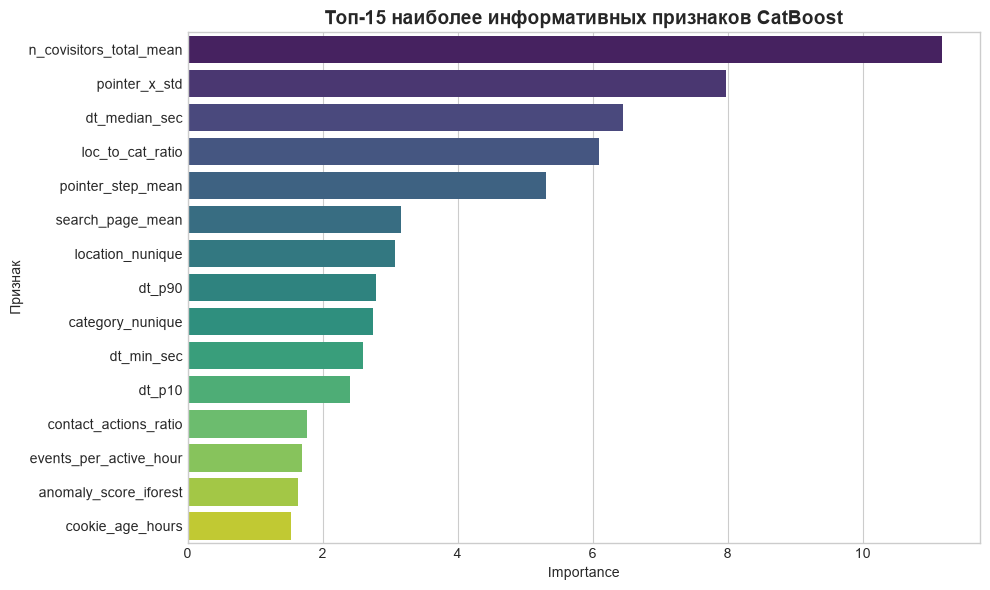

Топ-5 признаков по важности:
  n_covisitors_total_mean        | Важность: 11.18
  pointer_x_std                  | Важность: 7.97
  dt_median_sec                  | Важность: 6.45
  loc_to_cat_ratio               | Важность: 6.10
  pointer_step_mean              | Важность: 5.31


In [8]:
# Важность признаков усредняется по всем 5 моделям бэггинга (раздел 7) --
# это устойчивее, чем важность одной отдельной модели.
feature_importances = np.mean([m.get_feature_importance() for m in models], axis=0)
fi_df = pd.DataFrame({'feature': feature_cols, 'importance': feature_importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Топ-15 наиболее информативных признаков CatBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

print("Топ-5 признаков по важности:")
for i, row in fi_df.head(5).iterrows():
    print(f"  {row.feature:<30} | Важность: {row.importance:.2f}")

---

## 9. Формирование `submission.csv` и проверка формата


In [9]:
sample_sub = pd.read_csv('sample_submission.csv')

sub_raw = pd.DataFrame({
    'cookie_id': test_feats['cookie_id'],
    'score': test_scores_bagged
})

# Мержим через sample_submission, а не наоборот -- так порядок строк в итоговом файле
# гарантированно совпадает с шаблоном, даже если test_feats оказался в другом порядке.
sub = sample_sub[['cookie_id']].merge(sub_raw, on='cookie_id', how='left')
sub.to_csv('submission.csv', index=False)
print(f"[OK] Файл submission.csv успешно сохранён. Размер: {len(sub)} строк.")

# --- Проверки формата, требуемые условиями задачи ---
assert len(sub) == len(sample_sub), f"Ошибка: строк {len(sub)} != {len(sample_sub)}"
assert list(sub.columns) == ['cookie_id', 'score'], f"Ошибка структуры колонок: {sub.columns}"
assert (sub['cookie_id'] == sample_sub['cookie_id']).all(), "Ошибка: порядок cookie_id не совпадает с шаблоном"
assert not sub['score'].isna().any(), "Ошибка: найдены NaN в предсказаниях"
assert (sub['score'] >= 0.0).all() and (sub['score'] <= 1.0).all(), "Ошибка: скоры выходят за границы [0, 1]"
assert len(sub['score'].unique()) == len(sub), "Ошибка: присутствуют не-уникальные скоры (риск tie-групп)"


display(sub.head(5))

[OK] Файл submission.csv успешно сохранён. Размер: 4909 строк.


,cookie_id,score
0,ck_99a4e5ef02d89493,0.023320
1,ck_54d463f7fd89ec3d,0.038050
2,ck_0fbbc7a6af300368,0.008242
3,ck_8fd4937eadd64fb6,0.008308
4,ck_dbb4bd4eda97255d,0.038595


---

## 10. Итоги и известные ограничения

### Что сработало
1. **Строгий инвариант фильтрации окна** (`window_start_ts <= event_ts < window_end_ts`) — без него модель обучилась бы на утечке капчи «из будущего» и полностью провалилась бы на скрытом тесте, где такой утечки нет (разделы 2–3).
2. **Блок F (глубина пагинации + со-визитация объявлений)** — главный источник сигнала: `n_covisitors_total_mean` оказался самым важным признаком с большим отрывом (раздел 8).
3. **Блоки C (тайминги) и D (курсор на десктопе)** — закрывают быстрые скрипты и десктопных stealth-ботов независимо от блока F (см. стресс-тест в разделе 8).
4. **Мягкий upweighting мобильных ботов** — точечно поднял recall самого крупного и самого слабо покрытого архетипа, не просадив остальные.
5. **CatBoost как финальная модель** — нативно работает с категориальными признаками окружения (платформа, семейство ОС/браузера) без ручного энкодинга и на практике оказался не хуже более сложных ансамблей нескольких бустингов (раздел 6).

### Ограничения, о которых стоит знать
- **Кластер 2 (мобильные эмуляторы) — самое слабое место.** У него нет сигнала курсора мыши, а по остальным признакам он ближе всего к обычным мобильным пользователям среди всех 4 архетипов. Recall здесь заметно ниже, чем у остальных типов ботов (раздел 8).
- **Решение рассчитано на то, что скрытый test содержит трафик тех же известных сервисов, что и train.** LOCO-проверка (раздел 8) показывает, что принципиально новый, не представленный в train тип мобильного или stealth-бота будет обнаруживаться заметно хуже. Добавленный unsupervised anomaly score (блок I) частично, но не полностью компенсирует этот риск.
- **Holdout-оценка построена всего на 408 ботах** (Неделя 2 из train) — точечное значение метрики стоит воспринимать с поправкой на то, что при таком объёме позитивного класса оценка Precision в верхнем квантиле score может ощутимо колебаться от выборки к выборке.
- **Ансамбль нескольких бустингов** (протестирован на отдельном этапе экспериментов, раздел 6) статистически не отличим от одиночного CatBoost на имеющихся данных — усложнение архитектуры не включено в финал именно поэтому, а не из-за нехватки времени.

